# Anomaly Detection: make_blobs data

In [1]:
# imports
import matplotlib.pyplot as plt # for plotting
import numpy as np # for data manipulation and calculation

# for synthetic data creation and processing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# for implementation of the different methods of anomaly detection
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import KernelDensity
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

Synthetic X (first 10):
[[ 2.56991909 -0.35883507]
 [ 0.09276341  4.34551939]
 [ 2.20249345  5.47927434]
 [-1.52000169  3.33948563]
 [ 0.13742771  3.16777298]
 [ 9.18143495 -2.08416863]
 [ 0.42061579  4.1840797 ]
 [ 8.94850183 -1.75167482]
 [ 1.76351269  1.02302674]
 [ 1.67154287  1.3939503 ]]

Synthetic y_true (first 10):
[1 0 0 2 0 4 0 4 1 1]


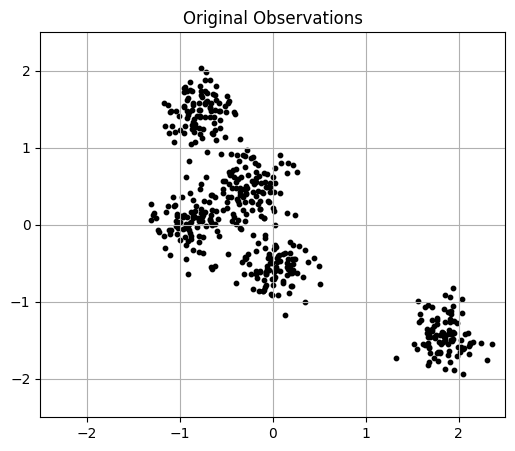

In [2]:
# creating synthetic data
# X: generated samples, y: integer labels for cluster membership of each sample
X, y_true = make_blobs(n_samples=500, 
                       centers=5,
                       cluster_std=0.80, 
                       random_state=0) 

print(f"Synthetic X (first 10):")
print(X[:10])
print()

print(f"Synthetic y_true (first 10):")
print(y_true[:10])

# scaling X 
X = StandardScaler().fit_transform(X)

# plotting X
fig = plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=10, color='k')
plt.axis([-2.5, 2.5, -2.5, 2.5])
plt.title("Original Observations")
plt.grid()
plt.show()

## Perform Elliptic Envelope

In [3]:
# making a meshgrid for plotting all surfaces (i.e. for the different clustering methdos)
Xp, Yp = np.meshgrid(np.linspace(-2.5,2.5),np.linspace(-2.5,2.5))
XY = np.vstack([Xp.ravel(), Yp.ravel()]).T

First Zp:
[[-124.28976881 -116.97667236 -109.91292991 -103.09854146  -96.53350701
   -90.21782656  -84.15150011  -78.33452765  -72.7669092   -67.44864475
   -62.3797343   -57.56017784  -52.98997539  -48.66912694  -44.59763248
   -40.77549203  -37.20270557  -33.87927312  -30.80519466  -27.9804702
   -25.40509975  -23.07908329  -21.00242084  -19.17511238  -17.59715792
   -16.26855746  -15.189311    -14.35941854  -13.77888009  -13.44769563
   -13.36586517  -13.53338871  -13.95026625  -14.61649778  -15.53208332
   -16.69702286  -18.1113164   -19.77496394  -21.68796548  -23.85032101
   -26.26203055  -28.92309409  -31.83351162  -34.99328316  -38.40240869
   -42.06088823  -45.96872176  -50.1259093   -54.53245083  -59.18834636]]

First y_pred:
[1]

First normals:
[[ 0.17947461 -0.88733023]]

First anomals:
[[ 2.02777644 -1.58125661]]



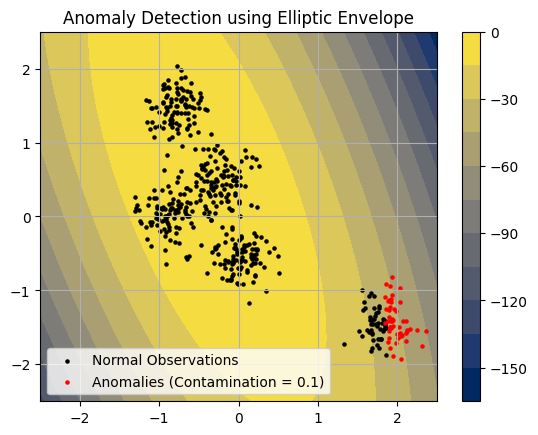

In [4]:
# creating and fitting an Elliptic Envelope
# fits the elliptic envelope model to the training data X; model learns the shape and size of the "normal" data distribution
envelope = EllipticEnvelope(random_state=0, contamination=0.1).fit(X)
Zp = envelope.score_samples(XY) # calculates the "anomaly score" for each point in the XY meshgrid (the higher the score, the more "normal" the point is)
Zp = Zp.reshape(Xp.shape)

# checking first Zp
print("First Zp:")
print(Zp[:1])
print()

# getting the anomalous data points
# predicts whether each point in the original data X is an inlier (normal, 1) or an outlier (anomaly, -1)
y_pred = envelope.predict(X)
normals = X[y_pred == 1, :] # extracts the normal data points from X
anomals = X[y_pred == -1, :] # extracts the anomalous data points from X

# checking first y_pred
print("First y_pred:")
print(y_pred[:1])
print()

# checking first normals
print("First normals:")
print(normals[:1])
print()

# checking first anomals
print("First anomals:")
print(anomals[:1])
print()

# creating a filled contour, plotting the normal points as black dots and anomalous data points as red dots
cntr = plt.contourf(Xp, Yp, Zp, levels=10, cmap='cividis')
plt.scatter(normals[:,0], normals[:,1], s=5, color='k', label='Normal Observations')
plt.scatter(anomals[:,0], anomals[:,1], s=5, color='r', label='Anomalies (Contamination = 0.1)')
plt.title('Anomaly Detection using Elliptic Envelope')
plt.colorbar(cntr)
plt.legend()
plt.grid()
plt.show()

The Elliptic Envelope assumes that the data has a multivariate Gaussian distribution. Hence, for non-Gaussian and/or multi-modal distributed data, this method fails to find anomalies well. Also, instead of a confidence level, the number of outliers to be detected by this method can be controlled by setting a contamination parameter. By default, this contamination parameter is set to 0.1. 

## Perform 2D Kernel Density Estimation

Threshold (KDE) = 0.1019869147985261


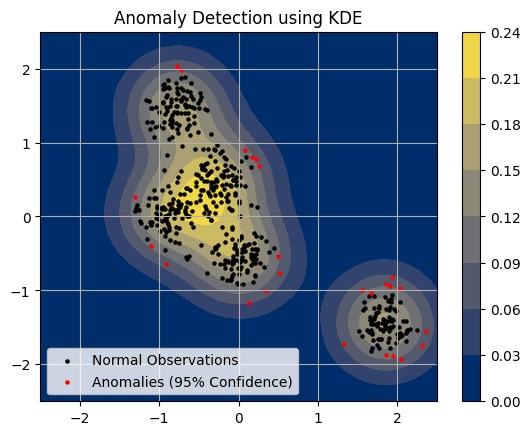

In [5]:
# generating a KDE surface as Z
# fits the KDE model to the data X, estimating the probability density function
kde = KernelDensity(kernel='gaussian', bandwidth=0.4).fit(X) # bandwidth: controls the width of the Gaussian kernels
Zp = np.exp(kde.score_samples(XY)) # calculates the log-likelihood of each point in the XY meshgrid under the estimated KDE model
Zp = Zp.reshape(Xp.shape)

# establishing a confidence level of 95% (or 5% cutoff) for the UCL using the quantile of kde_scores
scores = kde.score_samples(X)
threshold = np.quantile(scores, 0.05) # 5th percentile (0.05 quantile) of the log-likelihood scores used as a threshold to identify anomalies
print(f"Threshold (KDE) = {np.exp(threshold)}")

# getting the anomalous data points
# data points with scores < threshold are considered to be in the lowest 5% density area, and therefore anomalies
normals = X[scores > threshold, :] # extracts the normal data points from X, which have log-likelihood scores above the threshold
anomals = X[scores <= threshold, :] # extracts the anomalous data points from X, which have log-likelihood scores below or equal to the threshold

# creating a filled contour, plotting the normal points as black dots and anomalous data points as red dots
cntr = plt.contourf(Xp, Yp, Zp, cmap='cividis')
plt.scatter(normals[:,0], normals[:,1], s=5, color='k', label='Normal Observations')
plt.scatter(anomals[:,0], anomals[:,1], s=5, color='r', label='Anomalies (95% Confidence)')
plt.title('Anomaly Detection using KDE')
plt.colorbar(cntr)
plt.legend()
plt.grid()
plt.show()

In this implementation of KDE for anomaly detection, only the quantile statistic of the KDE scores was used to find anomalies. This approach only gives us an empirical threshold. The actual threshold should be computed by integrating the KDE score surface and finding the threshold $T$ such that $P(x < T) = \alpha$ for a given confidence level, $\alpha$. However, numerical double integration of surfaces takes a long time even for our example. 

## Perform One-class SVM

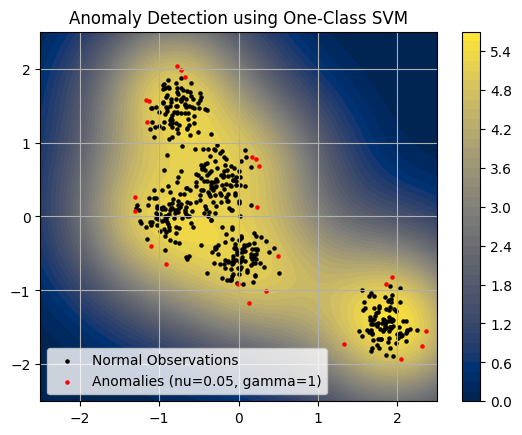

In [6]:
# creating and fitting a One-Class SVM Model
ocsvm = OneClassSVM(nu=0.05, gamma=1).fit(X) # nu: upper bound on the fraction of training errors and a lower bound on the fraction of support vectors
Zp = ocsvm.score_samples(XY) # calculates the "decision function" for each point in the XY meshgrid
Zp = Zp.reshape(Xp.shape)

# getting the anomalous data points
y_pred = ocsvm.predict(X) # predicts whether each point in the original data X is an inlier (normal, 1) or an outlier (anomaly, -1)
normals = X[y_pred == 1, :] # extracts the normal data points from X
anomals = X[y_pred == -1, :] # extracts the anomalous data points from X

# creating a filled contour, plotting the normal points as black dots and anomalous data points as red dots
cntr = plt.contourf(Xp, Yp, Zp, levels=50, cmap='cividis')
plt.scatter(normals[:,0], normals[:,1], s=5, color='k', label='Normal Observations')
plt.scatter(anomals[:,0], anomals[:,1], s=5, color='r', label='Anomalies (nu=0.05, gamma=1)')
plt.title('Anomaly Detection using One-Class SVM')
plt.colorbar(cntr)
plt.legend()
plt.grid()
plt.show()

OC-SVM is known to be sensitive to outliers that already exist in the training data. If these outliers are treated as "normal", or worse, as support vectors, then they will not be flagged as abnormal during testing time. Hence, OC-SVM is only suitable for novelty detection when the training data itself is not contaminated by too many outliers. This method is also efficient when it comes to novelty detection in high-dimensional data.

## Perform Local Outlier Factor

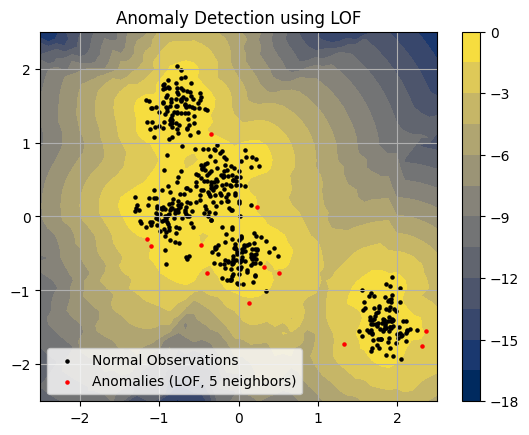

In [7]:
# creating and fitting a Local Outlier Factor Model
lof = LocalOutlierFactor(n_neighbors=5, novelty=True).fit(X) # n_neighbors: specifies the number of neighbors to consider when calculating the local density
Zp = lof.score_samples(XY) # calculates the negative LOF score for each point in the XY meshgrid
Zp = Zp.reshape(Xp.shape)

# getting the anomalous data points
y_pred = lof.predict(X) # predicts whether each point in the original data X is an inlier (normal, 1) or an outlier (anomaly, -1)
normals = X[y_pred == 1, :] # extracts the normal data points from X
anomals = X[y_pred == -1, :] # extracts the anomalous data points from X

# creating a filled contour, plotting the normal points as black dots and anomalous data points as red dots
cntr = plt.contourf(Xp, Yp, Zp, levels=10, cmap='cividis')
plt.scatter(normals[:,0], normals[:,1], s=5, color='k', label='Normal Observations')
plt.scatter(anomals[:,0], anomals[:,1], s=5, color='r', label='Anomalies (LOF, 5 neighbors)')
plt.title('Anomaly Detection using LOF')
plt.colorbar(cntr)
plt.legend()
plt.grid()
plt.show()

As seen in the result, the LOF tries to learn the shape of the data set based on the density of points. The less dense the data points, the more likely will they be treated as outliers. However, this also means that if data points are sparsely located **inside** the shape, the LOF will also treat them as outliers.

## Perform Isolation Forest

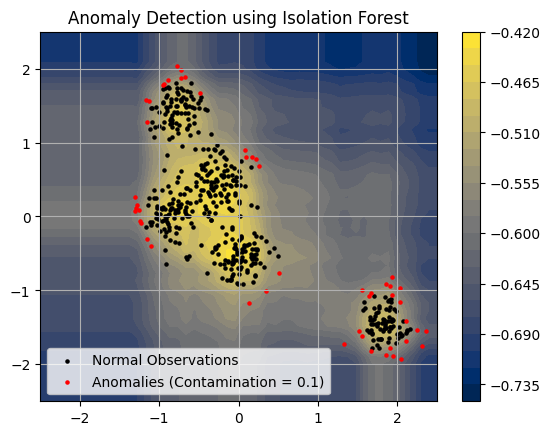

In [8]:
# creating and fitting an Isolation Forest Model
isoforest = IsolationForest(contamination=0.1).fit(X) # contamination: specifies the expected proportion of outliers in the data
Zp = isoforest.score_samples(XY) # anomaly score is based on the average path length of a point in the isolation trees
Zp = Zp.reshape(Xp.shape)

# getting the anomalous data points
y_pred = isoforest.predict(X) # predicts whether each point in the original data X is an inlier (normal, 1) or an outlier (anomaly, -1)
normals = X[y_pred == 1, :] # extracts the normal data points from X
anomals = X[y_pred == -1, :] # extracts the anomalous data points from X

# creating a filled contour, plotting the normal points as black dots and anomalous data points as red dots
cntr = plt.contourf(Xp, Yp, Zp, levels=20, cmap='cividis')
plt.scatter(normals[:,0], normals[:,1], s=5, color='k', label='Normal Observations')
plt.scatter(anomals[:,0], anomals[:,1], s=5, color='r', label='Anomalies (Contamination = 0.1)')
plt.title('Anomaly Detection using Isolation Forest')
plt.colorbar(cntr)
plt.legend()
plt.grid()
plt.show()

The Isolation Forest creates grid-like prediction surfaces in the entire space, due to the data splitting nature of the tree ensemble. However, for multi-modal distributed data such as in our example, areas of non-outlier predictions (green) somehow appear at other quadrants where the modes of the data meet, even if no data points are expected to appear there.

## Summary of the Five Anomaly Detection Methods:

| Method                 | Core Idea                                                              | Assumptions                                | Strengths                                                                | Weaknesses                                                                 | Key Parameters                               | Scikit-learn Implementation           |
| ---------------------- | ---------------------------------------------------------------------- | ------------------------------------------ | ------------------------------------------------------------------------ | -------------------------------------------------------------------------- | -------------------------------------------- | ----------------------------------------- |
| Elliptic Envelope      | Fits an ellipse/ellipsoid to the data, assuming a Gaussian distribution. | Data follows a Gaussian distribution.         | Simple, efficient, intuitive for Gaussian data.                       | Sensitive to non-Gaussian data, outliers in training, single-mode data. | `contamination`                               | `sklearn.covariance.EllipticEnvelope`      |
| Kernel Density Estimation (KDE) | Estimates the probability density using kernel functions.          | Data distribution can be modeled by kernels. | Flexible, can handle non-Gaussian data.                                  | Bandwidth selection is crucial, computationally intensive for large datasets. | `kernel`, `bandwidth`                        | `sklearn.neighbors.KernelDensity`        |
| One-Class SVM          | Learns a boundary around the normal data in a high-dimensional space. | Normal data can be enclosed by a boundary. | Effective for high-dimensional data, can handle complex boundaries.        | Sensitive to parameter tuning, can be computationally expensive.       | `nu`, `gamma`                                | `sklearn.svm.OneClassSVM`                |
| Local Outlier Factor (LOF) | Measures the local density deviation of a point from its neighbors.     | Anomalies have lower local density.         | Effective for local outliers, robust to varying densities.                 | Sensitive to `n_neighbors` selection, can be computationally expensive.      | `n_neighbors`                               | `sklearn.neighbors.LocalOutlierFactor`   |
| Isolation Forest       | Isolates anomalies by building random isolation trees.               | Anomalies are easily isolated.            | Efficient, handles high-dimensional data well, robust to irrelevant features. | Performance can be affected by random splits, requires careful tuning of contamination | `contamination`                              | `sklearn.ensemble.IsolationForest`      |